# Netflix Data Analysis

## 1. Import Libraries

In [1]:
# імпорт бібліотек
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
# завантаження датасету
df = pd.read_csv('netflix_titles.csv')

## 3. Dataset Overview

In [3]:
# перегляд 5 перших записів
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Отримуємо розмірність датасету: кількість спостережень (rows) та ознак (columns)
df.shape

(8807, 12)

In [5]:
# Перегляд назв колонок у датасеті
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
# перегляд типів даних у датасеті
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [7]:
# загальна інформація про таблицю# Перегляд структури датасету: типи даних та кількість non-null значень
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
# Підрахунок пропущених значень (NaN) у кожній колонці датасету
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## 4. Data Cleaning

In [9]:
# Перевірка наявності дубльованих рядків у датасеті
duplicated_rows = df.duplicated().sum()
duplicated_rows

np.int64(0)

In [10]:
# Заповнення пропущених значень у категоріальних колонках значенням 'Unknown'
for col in ['director', 'cast', 'country']:
    df[col] = df[col].fillna('Unknown')

In [11]:
# Конвертуємо 'date_added' у datetime та заповнюємо пропущені значення найчастішою датою.
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [12]:
# Виводимо всі рядки, де відсутнє значення у стовпці 'duration' для подальшого аналізу чи очищення.
df[df['duration'].isna()] 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [13]:
# Для рядків з пропущеним 'duration' переносимо значення з 'rating', 
# а в 'rating' ставимо None, щоб зберегти інформацію та очистити дані.
mask = df['duration'].isna()
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = None

In [14]:
# Видаляємо всі рядки, де відсутнє значення у стовпці 'rating', щоб уникнути пропущених даних у критично важливому полі.
df = df.dropna(subset=['rating'])

In [15]:
# Підраховуємо кількість пропущених значень у кожному стовпці для оцінки чистоти датасету після обробки.
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## 5. Feature Engineering

In [16]:
# Створюємо копію датасету, витягуємо числову частину з 'duration' у 'duration_int' 
# і додаємо порожні стовпці 'movie_minutes' та 'tv_seasons' для подальшого розділення тривалості на фільми та серіали.
df = df.copy()
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(int)
df['movie_minutes'] = pd.NA
df['tv_seasons'] = pd.NA

In [17]:
# Розподіляємо числову тривалість: для фільмів у 'movie_minutes', для серіалів у 'tv_seasons', 
# а потім видаляємо тимчасові стовпці 'duration' та 'duration_int'.
df.loc[df['type'] == 'Movie', 'movie_minutes'] = df['duration_int']
df.loc[df['type'] == 'TV Show', 'tv_seasons'] = df['duration_int']
df = df.drop(columns=['duration','duration_int'])

In [18]:
# Перетворюємо стовпці 'movie_minutes' та 'tv_seasons' у числовий формат, замінюючи некоректні значення на NaN для коректного аналізу.
df['movie_minutes'] = pd.to_numeric(df['movie_minutes'], errors='coerce')
df['tv_seasons'] = pd.to_numeric(df['tv_seasons'], errors='coerce')

## 6. Exploratory Data Analysis

In [19]:
# Підраховуємо кількість унікальних значень у стовпці 'rating', щоб оцінити розподіл рейтингів у датасеті.
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [20]:
# Підраховуємо кількість фільмів і серіалів у стовпці 'type', щоб оцінити баланс типів контенту в датасеті.
df['type'].value_counts()

type
Movie      6126
TV Show    2674
Name: count, dtype: int64

In [21]:
# Виводимо топ-10 країн за кількістю контенту, щоб зрозуміти, які країни найактивніше представлені у датасеті.
df['country'].value_counts().head(10)

country
United States     2815
India              972
Unknown            830
United Kingdom     419
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [22]:
# Підраховуємо кількість контенту за роками випуску та сортуємо за хронологією для аналізу динаміки виходу фільмів і серіалів.
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

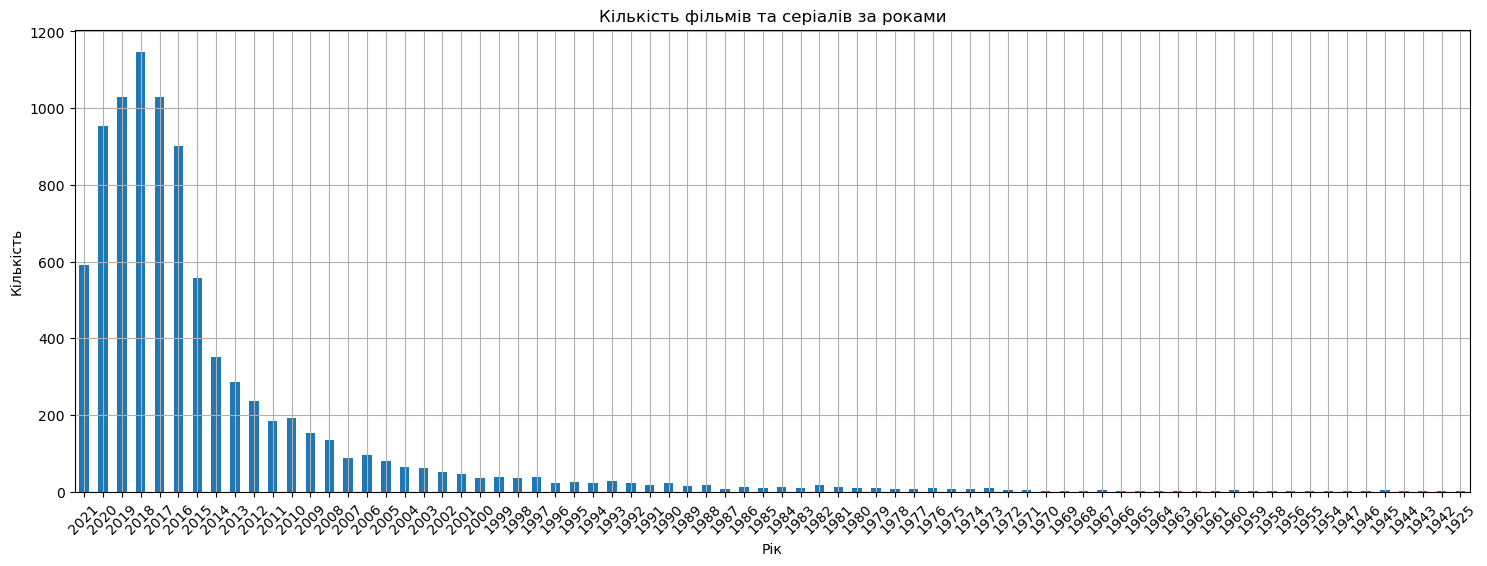

In [23]:
# Групуємо дані за роком випуску, рахуємо кількість шоу, сортуємо за роками у зворотному порядку 
# та будуємо стовпчикову діаграму для візуалізації трендів виходу фільмів і серіалів.
df.groupby('release_year')['show_id'].count().sort_index(ascending=False).plot(
    kind='bar',
    title='Кількість фільмів та серіалів за роками',
    figsize=(18,6),
    rot=45,
    grid=True
)
plt.xlabel('Рік')
plt.ylabel('Кількість')
plt.show()

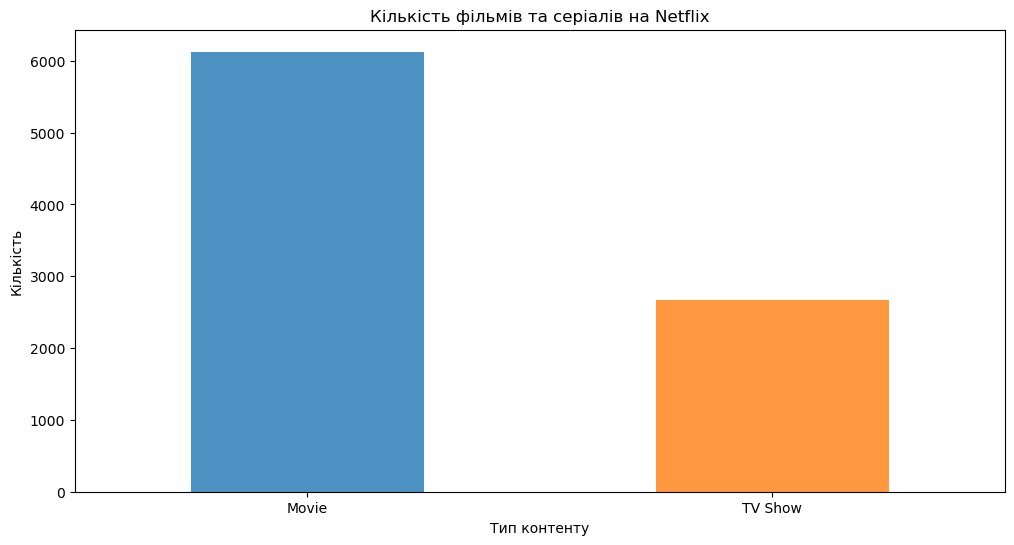

In [24]:
# Групуємо дані за типом ('Movie' або 'TV Show'), рахуємо кількість шоу 
# та будуємо стовпчикову діаграму для порівняння числа фільмів і серіалів на Netflix.
df.groupby('type')['show_id'].count().plot(
    kind='bar',
    color=['#1f77b4', '#ff7f0e'],
    figsize=(12,6),
    title='Кількість фільмів та серіалів на Netflix',
    alpha=0.8,
    rot=0
)
plt.xlabel('Тип контенту')
plt.ylabel('Кількість')
plt.show()

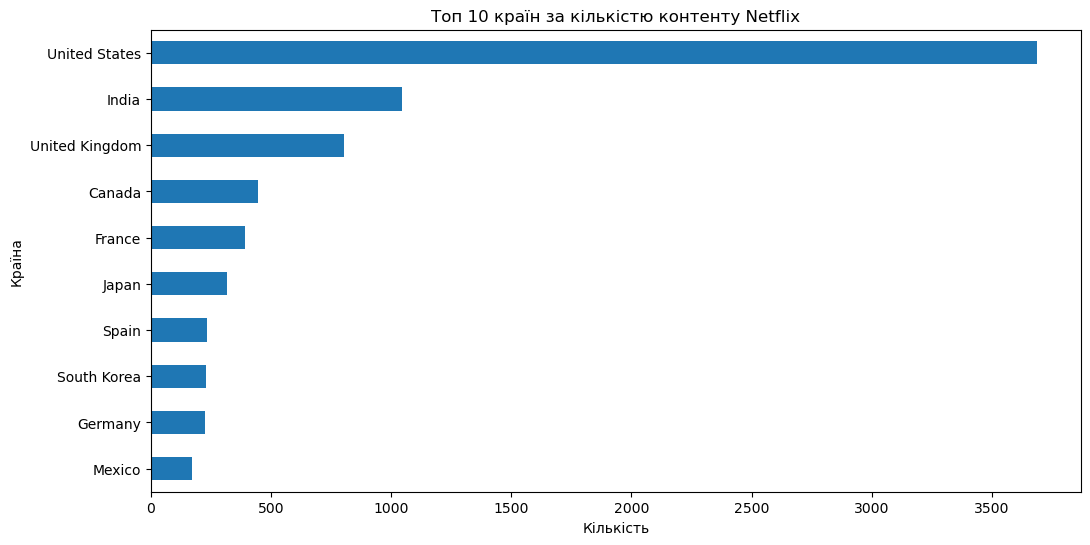

In [25]:
# Відбираємо відомі країни, розділяємо мультирегійні записи, підраховуємо кількість шоу по країнах, 
# беремо топ-10 та будуємо горизонтальну діаграму для візуалізації найактивніших країн за контентом Netflix.
countries = (
    df[df['country'] != 'Unknown']['country']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)
countries.sort_values().plot(
    kind='barh',
    figsize=(12,6),
    title='Топ 10 країн за кількістю контенту Netflix'
)
plt.xlabel('Кількість')
plt.ylabel('Країна')
plt.show()

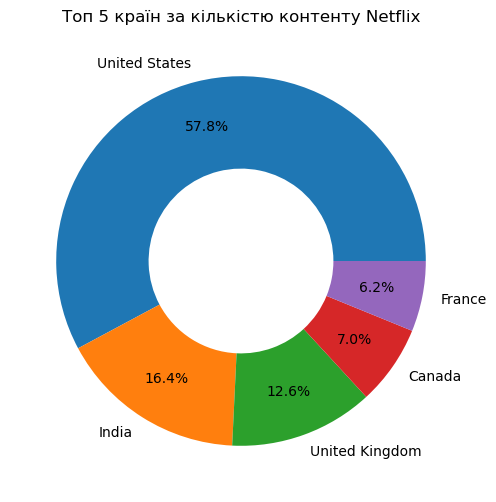

In [26]:
# Візуалізуємо топ-5 країн за кількістю контенту на Netflix у вигляді кругової діаграми з внутрішнім відсіченням для наочного порівняння часток.
top5_countries = countries.head(5)
top5_countries.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    title='Топ 5 країн за кількістю контенту Netflix',
    wedgeprops={'width': 0.5},
    pctdistance=0.75
)
plt.ylabel('')
plt.show()

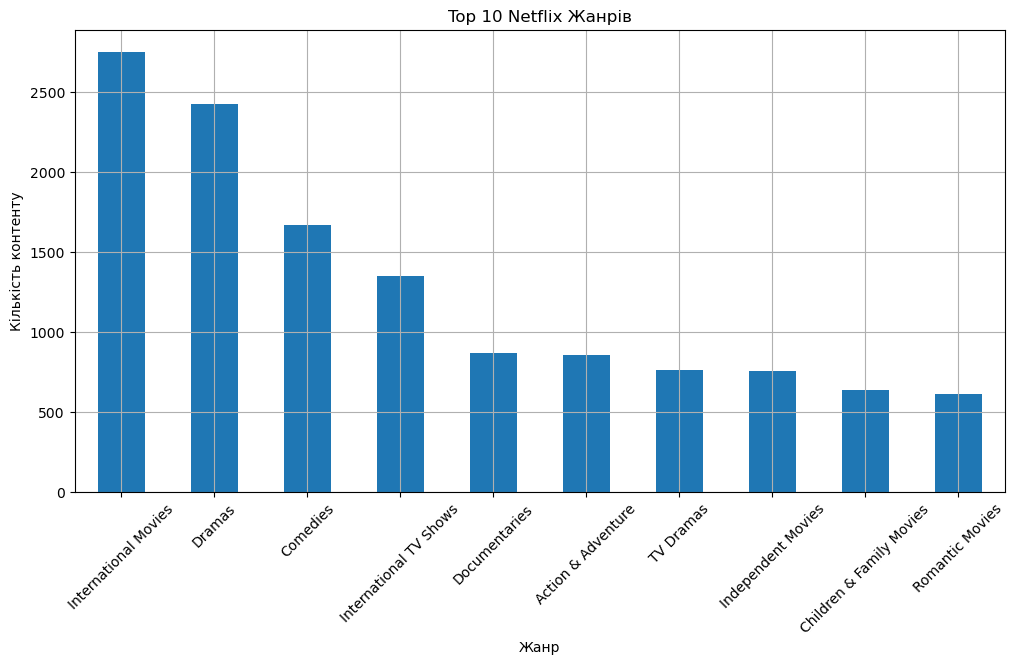

In [27]:
# Створюємо копію датасету, розбиваємо мультіжанрові записи на окремі жанри, підраховуємо кількість шоу по жанрах, 
# беремо топ-10 та будуємо стовпчикову діаграму для аналізу популярних жанрів на Netflix.
df_genres = df.copy()
df_genres['genre'] = df_genres['listed_in'].str.split(', ')
df_genres = df_genres.explode('genre')

top_genres = (
    df_genres['genre']
    .value_counts()
    .head(10)
)
top_genres.plot(
    kind='bar',
    figsize=(12,6),
    title='Top 10 Netflix Жанрів',
    rot=45,
    grid=True
)

plt.xlabel('Жанр')
plt.ylabel('Кількість контенту')
plt.show()

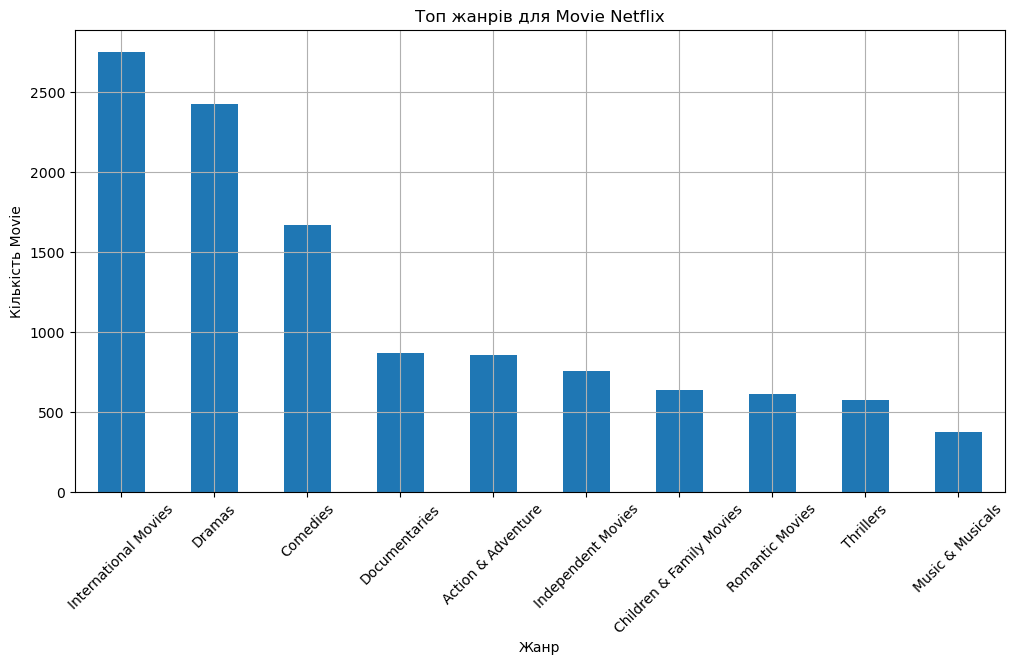

In [28]:
# Відбираємо тільки фільми, підраховуємо кількість шоу по жанрах, 
# беремо топ-10 та будуємо стовпчикову діаграму для аналізу популярних жанрів серед Movie на Netflix.
movie_genres = (
    df_genres[df_genres['type'] == 'Movie']['genre']
    .value_counts()
    .head(10)
)
movie_genres.plot(
    kind='bar',
    figsize=(12,6),
    title='Топ жанрів для Movie Netflix',
    rot=45,
    grid=True
)
plt.xlabel('Жанр')
plt.ylabel('Кількість Movie')
plt.show()

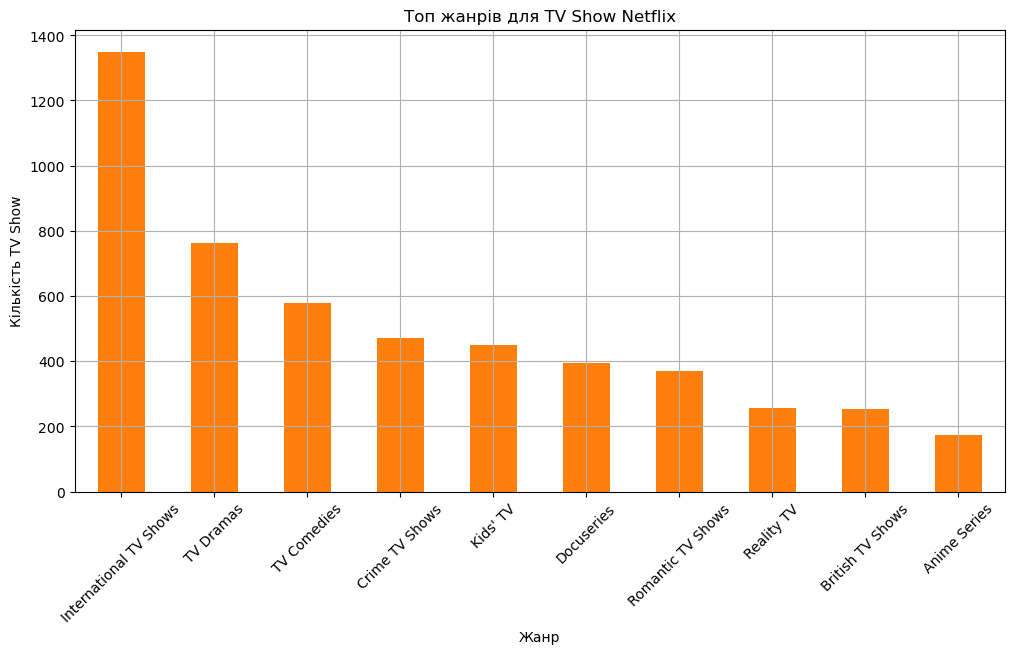

In [29]:
# Відбираємо тільки серіали, підраховуємо кількість шоу по жанрах, 
# беремо топ-10 та будуємо стовпчикову діаграму для аналізу популярних жанрів серед TV Show на Netflix.
movie_genres = (
    df_genres[df_genres['type'] == 'TV Show']['genre']
    .value_counts()
    .head(10)
)
movie_genres.plot(
    kind='bar',
    figsize=(12,6),
    title='Топ жанрів для TV Show Netflix',
    rot=45,
    grid=True,
    color='#ff7f0e'
)
plt.xlabel('Жанр')
plt.ylabel('Кількість TV Show')
plt.show()

In [30]:
# Відбираємо відомих режисерів, розділяємо мультирежисерські записи, підраховуємо кількість шоу по кожному режисеру 
# та виводимо топ-10 найбільш продуктивних режисерів на Netflix.
directors = (
    df[df['director'] != 'Unknown']['director']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)
directors

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

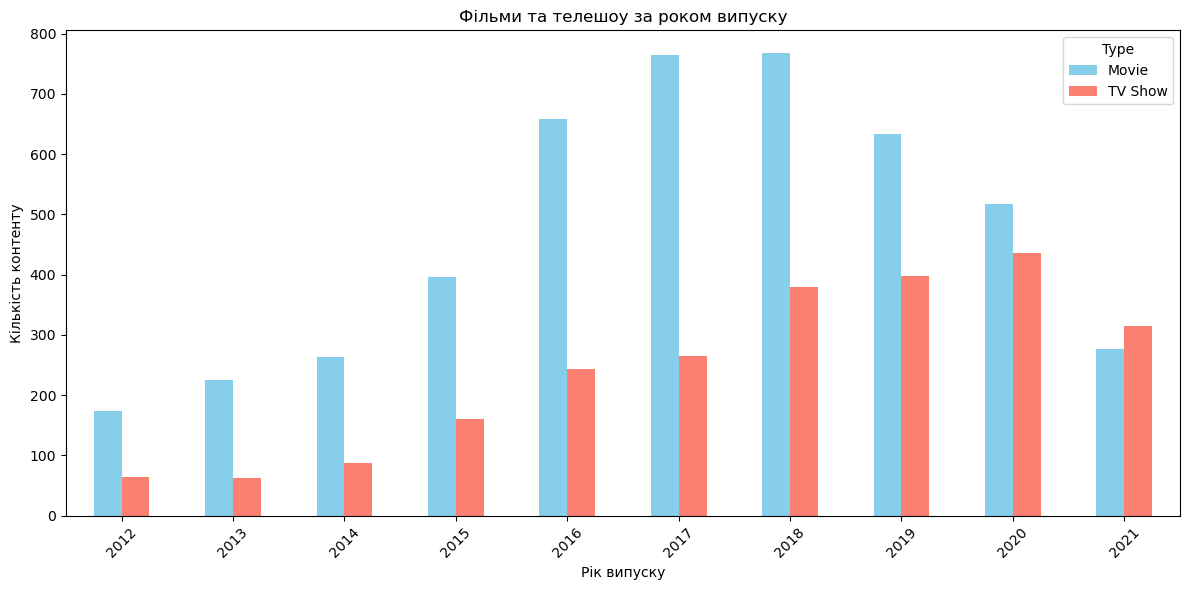

In [31]:
# Групуємо дані за роком випуску та типом контенту, рахуємо кількість шоу, 
# перетворюємо у формат для побудови стовпчикової діаграми з порівнянням Movie та TV Show по роках та візуалізуємо тренди.
count_content_by_releasedyear = df.groupby(['release_year','type']).size().sort_index(ascending=False).head(20)

df_plot = count_content_by_releasedyear.reset_index(name='count')
df_plot = df_plot.pivot(index='release_year', columns='type', values='count')

df_plot.plot(
    kind='bar',
    figsize=(12,6),
    color=['skyblue', 'salmon']
)

plt.xlabel('Рік випуску')
plt.ylabel('Кількість контенту')
plt.title('Фільми та телешоу за роком випуску')
plt.legend(title='Type') 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Виводимо топ-5 найдовших фільмів за тривалістю ('movie_minutes') з назвами для аналізу рекордсменів за часом перегляду.
df[df['type']=='Movie'].nlargest(5, 'movie_minutes')[['title', 'movie_minutes']]

,title,movie_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0


In [33]:
# Виводимо топ-5 серіалів з найбільшою кількістю сезонів ('tv_seasons') для аналізу найтриваліших шоу на Netflix.
df[df['type']=='TV Show'].nlargest(5, 'tv_seasons')[['title','tv_seasons']]

,title,tv_seasons
548,Grey's Anatomy,17.0
2423,Supernatural,15.0
4798,NCIS,15.0
1354,Heartland,13.0
4220,COMEDIANS of the world,13.0


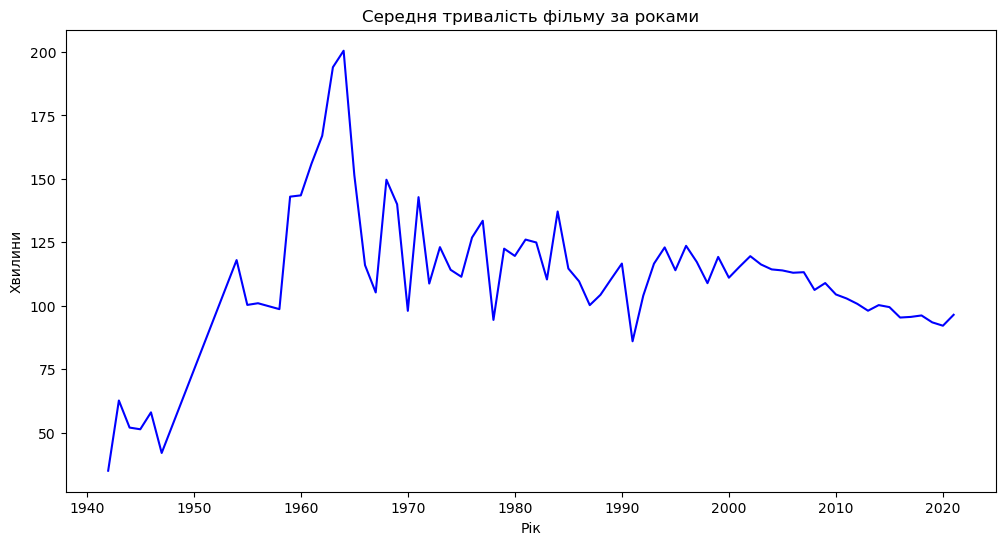

In [34]:
# Обчислюємо середню тривалість фільмів за роками та будуємо лінійну діаграму для аналізу тенденцій зміни тривалості фільмів на Netflix.
df_movies = df[df['type']=='Movie'].groupby('release_year')['movie_minutes'].mean()
df_movies.plot(
    kind='line',
    figsize=(12,6),
    color='blue'
)
plt.title('Середня тривалість фільму за роками')
plt.xlabel('Рік')
plt.ylabel('Хвилини')
plt.show()

## 7. Conclusions

- Після 2016 року кількість нового контенту на Netflix почала стрімко зростати, що може свідчити про активне масштабування платформи та збільшення інвестицій у виробництво.

- У каталозі платформи домінують фільми: їхня частка значно перевищує кількість серіалів, що вказує на орієнтацію сервісу на кіноформат.

- США є основним виробником контенту для платформи, значно випереджаючи інші країни за кількістю представлених тайтлів.

- Найбільш поширеними жанрами в каталозі є драма та комедія, що може відображати загальні вподобання аудиторії.

- Більшість фільмів має тривалість у межах 90–120 хвилин, що відповідає стандартному формату повнометражного кіно.